# Entraînement et évaluation

Le but du notebook est : 
- Le chargement et la préparation des données
- La recherche d'hyperparamètres
- La définition des modèles
- L'entraînement des modèles
- Leur comparaison d'efficacité
- leur évaluation face à un modèle GDD

## Configuration

In [42]:
#Configuration
srcFile = "../data/processed/consolidated/consolidated.parquet"
evaluationStatsFile = "../models/stats-modeles.csv"
modelsFolder = "../models/"

In [43]:
#Chargement des librairies
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import pickle
import numpy as np
import gc

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV



## Chargement et préparation des données

In [44]:
#Chargement des données consolidées
df = pd.read_parquet(srcFile, engine="fastparquet")

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736479 entries, 0 to 1736478
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   latitude           float64
 1   longitude          float64
 2   altitude           float64
 3   n_avant_floraison  int64  
 4   jour_n             int64  
 5   temps_thermique10  float64
 6   chilling_hivernal  int64  
 7   date               float64
 8   annee              int64  
dtypes: float64(5), int64(4)
memory usage: 119.2 MB


In [46]:
#Vérif valeurs manquantes
df.isnull().sum()

latitude             0
longitude            0
altitude             0
n_avant_floraison    0
jour_n               0
temps_thermique10    0
chilling_hivernal    0
date                 0
annee                0
dtype: int64

In [47]:
df

,latitude,longitude,altitude,n_avant_floraison,jour_n,temps_thermique10,chilling_hivernal,date,annee
0,47.96686,7.25566,432.0,151,1,0.0,37,20150101.0,2015
1,47.96686,7.25566,432.0,150,2,0.0,38,20150102.0,2015
2,47.96686,7.25566,432.0,149,3,0.0,39,20150103.0,2015
3,47.96686,7.25566,432.0,148,4,0.0,40,20150104.0,2015
4,47.96686,7.25566,432.0,147,5,0.0,41,20150105.0,2015
...,...,...,...,...,...,...,...,...,...
1736474,46.21100,-1.51457,3.0,-210,361,1748.3,44,20181227.0,2018
1736475,46.21100,-1.51457,3.0,-211,362,1748.3,44,20181228.0,2018
1736476,46.21100,-1.51457,3.0,-212,363,1748.3,45,20181229.0,2018
1736477,46.21100,-1.51457,3.0,-213,364,1748.3,45,20181230.0,2018


In [ ]:
#Séparation X et y
# Il faut garantir qu'aucune trajectoire (site×année) ne se retrouve à la fois dans le train et dans la validation (fuite de données)

#On sépare les X et y (on supprime de X le label ainsi que date qui n'est pas utile dans notre cas)
y = df["n_avant_floraison"]
X = df.drop(["n_avant_floraison", "date"], axis=1)

jour_floraison = (y + X['jour_n']).astype(str)
#Séries de chaines de caractères qui sont des identifiant unique par site/année (càd trajectoire)
groupes = (
    X['latitude'].astype(str) + '_' +
    X['longitude'].astype(str) + '_' +
    X['annee'].astype(str) + '_' +
    jour_floraison
)
print(f"Nombre de groupes site×année : {groupes.nunique()}")

#Sépare les données par groupe entier et pas par ligne individuel. 20% des groupes dans la validation
#Pour éviter la fuite de données, càd des trajectoires qui se retrouvent à la fois en train et validation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(gss.split(X, y, groupes))

X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
X_valid = X.iloc[valid_idx].reset_index(drop=True)
y_valid = y.iloc[valid_idx].reset_index(drop=True)

print(f"Lignes entraînement : {X_train.shape[0]:,}")
print(f"Lignes validation   : {X_valid.shape[0]:,}")

Nombre de groupes site×année : 4754
Lignes entraînement : 1,389,120
Lignes validation   : 347,359


## Recherche d'hyperparamètres

### Gradient Boosting

In [ ]:

param_dist = {
    'loss': ['squared_error', 'absolute_error', 'huber'],
    'learning_rate': uniform(0.01, 0.19),
    'n_estimators': randint(50, 201),
    'max_depth': [3, 4, 5]
}

search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,         
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=2,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print("Meilleurs paramètres:", search.best_params_)
print("Meilleur score:", search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres: {'learning_rate': np.float64(0.15814129005182617), 'loss': 'squared_error', 'max_depth': 5, 'n_estimators': 171}
Meilleur score: -28.885177469226676


### KNN

In [ ]:
#Pour le KNN : estimation du meilleur K
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

k_values = range(1, 31)
cv_scores = []
cv_std = []

for k in k_values:
    pipeline = Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', KNeighborsRegressor(n_neighbors=k))
        ]
    )

    # Validation croisée
    scores = cross_val_score(pipeline, X_train, y_train, 
                            cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # Convertir en MSE positif
    cv_std.append(scores.std())


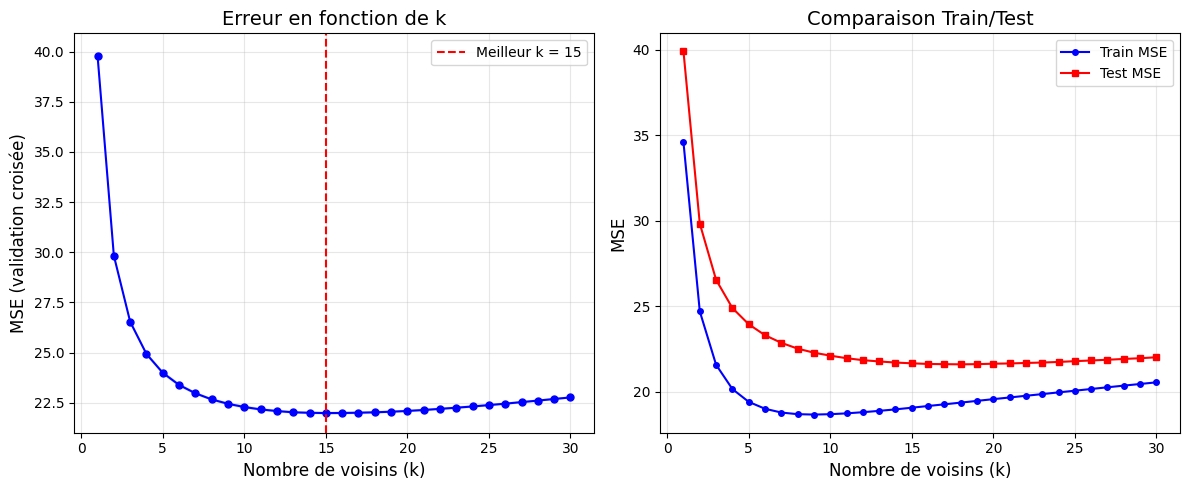

Meilleur k : 15
MSE minimal : 21.9890


In [ ]:
# Visualisation

plt.figure(figsize=(12, 5))

# MSE en fonction de k
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, 'b-', marker='o', markersize=5)
plt.fill_between(k_values, 
                 np.array(cv_scores) - np.array(cv_std),
                 np.array(cv_scores) + np.array(cv_std),
                 alpha=0.2)
plt.xlabel('Nombre de voisins (k)', fontsize=12)
plt.ylabel('MSE (validation croisée)', fontsize=12)
plt.title('Erreur en fonction de k', fontsize=14)
plt.grid(True, alpha=0.3)

# Identifier le meilleur k
best_k = k_values[np.argmin(cv_scores)]
plt.axvline(x=best_k, color='r', linestyle='--', 
            label=f'Meilleur k = {best_k}')
plt.legend()


plt.subplot(1, 2, 2)
train_scores = []
test_scores = []

for k in k_values:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    pipeline.fit(X_train, y_train)
    
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_valid)
    
    train_scores.append(mean_squared_error(y_train, train_pred))
    test_scores.append(mean_squared_error(y_valid, test_pred))

plt.plot(k_values, train_scores, 'b-', marker='o', 
         markersize=4, label='Train MSE')
plt.plot(k_values, test_scores, 'r-', marker='s', 
         markersize=4, label='Test MSE')
plt.xlabel('Nombre de voisins (k)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Comparaison Train/Test', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Meilleur k : {best_k}")
print(f"MSE minimal : {min(cv_scores):.4f}")

### Forêt aléatoire

In [ ]:
rfr = RandomForestRegressor(
    random_state=42,
    n_jobs=1          #
)

param_dist = {
    'n_estimators': randint(50, 201),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'max_samples': uniform(0.5, 0.5)  
}

search = HalvingRandomSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    factor=3,          
    resource='n_samples',
    min_resources='smallest',
    n_jobs=2,         
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Meilleurs paramètres:", search.best_params_)
print("Meilleur score:", search.best_score_)

n_iterations: 10
n_required_iterations: 10
n_possible_iterations: 10
min_resources_: 10
max_resources_: 500000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50000
n_resources: 10
Fitting 5 folds for each of 50000 candidates, totalling 250000 fits
----------
iter: 1
n_candidates: 16667
n_resources: 30
Fitting 5 folds for each of 16667 candidates, totalling 83335 fits
----------
iter: 2
n_candidates: 5556
n_resources: 90
Fitting 5 folds for each of 5556 candidates, totalling 27780 fits
----------
iter: 3
n_candidates: 1852
n_resources: 270
Fitting 5 folds for each of 1852 candidates, totalling 9260 fits
----------
iter: 4
n_candidates: 618
n_resources: 810
Fitting 5 folds for each of 618 candidates, totalling 3090 fits
----------
iter: 5
n_candidates: 206
n_resources: 2430
Fitting 5 folds for each of 206 candidates, totalling 1030 fits
----------
iter: 6
n_candidates: 69
n_resources: 7290
Fitting 5 folds for each of 69 candidates, totalling 345 fits
----------


/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 9
n_candidates: 3
n_resources: 196830
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Meilleurs paramètres: {'max_depth': 20, 'max_features': 0.5, 'max_samples': np.float64(0.9709321177823373), 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 134}
Meilleur score: -33.784059287348086


## Entraînement et évaluation des modèles

In [ ]:
#Fonctions pour validations croisées

def vc_lasso(X_train, X_valid, y_train, y_valid):
    # LassoCV doit tourner sur des données normalisées
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    lasso_cv = LassoCV(alphas=100, cv=5, max_iter=10000)
    lasso_cv.fit(X_train_scaled, y_train)
    print(f"Meilleur alpha: {lasso_cv.alpha_}")
    return lasso_cv.alpha_

def vc_elasticnet(X_train, X_valid, y_train, y_valid):
    # ElasticNetCV doit aussi tourner sur des données normalisées
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    en_cv = ElasticNetCV(alphas=100, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=10000)
    en_cv.fit(X_train_scaled, y_train)
    print(f"Meilleur alpha: {en_cv.alpha_}, meilleur l1_ratio: {en_cv.l1_ratio_}")
    return en_cv.alpha_, en_cv.l1_ratio_

def vc_ridge(X_train, X_valid, y_train, y_valid):
    ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
    ridge_cv.fit(X_train, y_train)
    print(f"Meilleur alpha: {ridge_cv.alpha_}")
    return ridge_cv.alpha_

In [52]:
#Configuration des modèles
modeles = {
    'Régression Lineaire' : {
        'model' : LinearRegression,
        'normalisation' : True,
        'vc' : None,
        'arguments' : {},
        'filename' : 'regressionlineaire.pkl'
    },
    'Régression pénalisée Ridge L2' : {
        'model' : Ridge,
        'normalisation' : True,
        'vc' : vc_ridge,
        'vcArg' : 'alpha',
        'arguments' : {'alpha' : 1.0},
        'filename' : 'regressionpenalisee_l2.pkl'
    },
    'Régression pénalisée Lasso L1' : {
        'model' : Lasso,
        'normalisation' : True,
        'vc' :  vc_lasso,
        'vcArg' : 'alpha',
        'arguments' : {'alpha' : 1.0, 'max_iter' : 10000},
        'filename' : 'regressionpenalisee_l1.pkl'
    },
    'Régression pénalisée ElasticNet' : {
        'model' : ElasticNet,
        'normalisation' : True,
        'vc' : vc_elasticnet,
        'vcArg' : ('alpha', 'l1_ratio'),
        'arguments' : {'alpha' : 1.0, 'l1_ratio' : 0.5, 'max_iter' : 10000},
        'filename' : 'regressionpenalisee_elastic.pkl'
    },
    'KNN' : {
        'model' : KNeighborsRegressor,
        'normalisation' : True,
        'vc' : None,
        'arguments' : {'n_neighbors' : 15},
        'filename' : 'KNN.pkl'
    },
    'Arbre de décision' : {
        'model' : tree.DecisionTreeRegressor,
        'normalisation' : False,
        'vc' : None,
        'arguments' : {'criterion' : 'squared_error'},
        'filename' : 'decisiontree.pkl'
    },
    'Forêt aléatoire' : {
        'model' : RandomForestRegressor,
        'normalisation' : False,
        'vc' : None,
        'arguments' : {'n_estimators' : 134, 'random_state' : 0, 'max_depth': 20, 'max_features': 0.5, 'max_samples': np.float64(0.9709321177823373), 'min_samples_leaf': 1, 'min_samples_split': 4},
        'filename' : 'randomforest.pkl'
    },
    'Gradient boosting' : {
        'model' : GradientBoostingRegressor,
        'normalisation' : False,
        'vc' : None,
        'arguments' : {'learning_rate': 0.2, 'loss': 'squared_error', 'max_depth': 7, 'n_estimators': 200},
        'filename' : 'gradientboosting.pkl'
    },
}

In [53]:

#Fonction d'entrainement
from time import time
import pickle
import os


#Données de tracking
tracking = {
    'model' : [],
    'trainingTime' : [],

    #MAE : nombre de jours moyens d'erreur
    'mae_train' : [],
    'mae_valid' : [],

    #RMSE : idem mais avec pénalisation des erreurs "graves"
    'rmse_train' : [],
    'rmse_valid' : [],

    #% de prédictions justes à +/- 3 jours et 7 jours
    'pct3j_valid' : [],
    'pct7j_valid' : [],

    #Taille du modèle
    'poids' : []
}


def train_modele(modeleName, modelConfig, X_train, X_valid, y_train, y_valid, tracking):
    print("=============================================================")
    print(f"Entrainement du modèle {modeleName}")

    tracking["model"].append(modeleName)

    #Validation croisée
    if modelConfig["vc"]:
        print("Validation croisée !")
        result = modelConfig["vc"](X_train, X_valid, y_train, y_valid)
        vcArg = modelConfig["vcArg"]
        # Supporte un seul argument ou un tuple d'arguments
        if isinstance(vcArg, tuple):
            for key, val in zip(vcArg, result):
                modelConfig["arguments"][key] = val
        else:
            modelConfig["arguments"][vcArg] = result

    print(modelConfig["arguments"])

    #Normalisation
    steps = []
    if modelConfig["normalisation"]:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', modelConfig["model"](**modelConfig["arguments"])))
    pipeline = Pipeline(steps=steps)

    #Entraîne le modèle
    ms_start = int(time() * 1000)
    pipeline.fit(X_train, y_train)
    ms_end = int(time() * 1000)
    print(f"Entraînement terminé en {ms_end-ms_start} ms")
    tracking["trainingTime"].append(ms_end-ms_start)

    #Prédictions globales
    y_pred_valid = pipeline.predict(X_valid)
    y_pred_train = pipeline.predict(X_train)

    # MAE
    score_mae_valid = mean_absolute_error(y_valid, y_pred_valid)
    score_mae_train = mean_absolute_error(y_train, y_pred_train)
    print('MAE (jeu de validation) :', score_mae_valid)
    print("MAE (jeu d\'entraînement) :", score_mae_train)

    # RMSE
    score_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    score_rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
    print('RMSE (jeu de validation) :', score_rmse_valid)
    print("RMSE (jeu d\'entraînement) :", score_rmse_train)


    # % de prédictions dans une fenêtre de ±3j et ±7j
    pct3j_valid = np.mean(np.abs(np.array(y_valid) - y_pred_valid) <= 3) * 100
    pct7j_valid = np.mean(np.abs(np.array(y_valid) - y_pred_valid) <= 7) * 100
    print(f'% à ±3 jours (valid) : {pct3j_valid:.1f}%')
    print(f'% à ±7 jours (valid) : {pct7j_valid:.1f}%')

    tracking["mae_train"].append(score_mae_train)
    tracking["mae_valid"].append(score_mae_valid)
    tracking["rmse_train"].append(score_rmse_train)
    tracking["rmse_valid"].append(score_rmse_valid)
    tracking["pct3j_valid"].append(pct3j_valid)
    tracking["pct7j_valid"].append(pct7j_valid)


    pickle.dump(pipeline, open(f"{modelsFolder}{modelConfig['filename']}", 'wb'))
    taille_model = os.path.getsize(f"{modelsFolder}{modelConfig['filename']}") / 1024
    print(f"Taille du modèle {taille_model} ko")
    tracking["poids"].append(taille_model)

    print("Quelques exemples de prédictions : ")
    for index in range(0, 5):
        print(f"Valeur réelle : {y_valid.iloc[index]} - valeur prédite : {y_pred_valid[index]:.1f}")

    return tracking


In [54]:
#Entrainement et évaluation
for modele in modeles:
    tracking = train_modele(modele, modeles[modele], X_train, X_valid, y_train, y_valid, tracking)

Entrainement du modèle Régression Lineaire
{}
Entraînement terminé en 396 ms
MAE (jeu de validation) : 6.5985980845164605
MAE (jeu d'entraînement) : 6.920354429947979
RMSE (jeu de validation) : 8.384724122695538
RMSE (jeu d'entraînement) : 8.952875612156758
% à ±3 jours (valid) : 30.7%
% à ±7 jours (valid) : 60.0%
Taille du modèle 1.2470703125 ko
Quelques exemples de prédictions : 
Valeur réelle : 151 - valeur prédite : 155.4
Valeur réelle : 150 - valeur prédite : 154.4
Valeur réelle : 149 - valeur prédite : 153.4
Valeur réelle : 148 - valeur prédite : 152.4
Valeur réelle : 147 - valeur prédite : 151.5
Entrainement du modèle Régression pénalisée Ridge L2
Validation croisée !
Meilleur alpha: 0.1
{'alpha': np.float64(0.1)}
Entraînement terminé en 150 ms
MAE (jeu de validation) : 6.598598990120177
MAE (jeu d'entraînement) : 6.920354898275707
RMSE (jeu de validation) : 8.384724368817727
RMSE (jeu d'entraînement) : 8.952875612194909
% à ±3 jours (valid) : 30.7%
% à ±7 jours (valid) : 60.0%


In [55]:
# Conversion en dataframe
tracking_df = pd.DataFrame(tracking, columns=[
    "model", "trainingTime",
    "mae_train", "mae_valid",
    "rmse_train", "rmse_valid",
    "pct3j_valid", "pct7j_valid",
    "poids"
])
tracking_df

,model,trainingTime,mae_train,mae_valid,rmse_train,rmse_valid,pct3j_valid,pct7j_valid,poids
0,Régression Lineaire,396,6.920354,6.598598,8.952876,8.384724,30.671150,59.975414,1.247070e+00
1,Régression pénalisée Ridge L2,150,6.920355,6.598599,8.952876,8.384724,30.670574,59.975414,1.222656e+00
2,Régression pénalisée Lasso L1,407,6.908558,6.584328,8.956597,8.397995,31.018341,60.305908,1.299805e+00
3,Régression pénalisée ElasticNet,557,7.431077,7.158833,9.522007,9.039506,26.209484,57.223794,1.314453e+00
4,KNN,1331,3.140075,6.219669,4.368348,8.120785,29.790505,67.485224,1.068902e+05
5,Arbre de décision,7089,2.678613,5.945374,4.142524,7.644293,30.384415,73.090376,8.919351e+04
6,Forêt aléatoire,267414,3.234736,5.022680,4.459588,6.446312,35.477705,75.358635,2.920313e+06
7,Gradient boosting,656947,3.242284,5.333548,4.432292,6.717495,31.939290,72.449253,3.603521e+03


In [56]:
#Calcul temps inférence (sur 100 lignes)
import time

N_ROWS = 100

X_sample = X_valid.iloc[:N_ROWS]

inference_times = {}

for modele in modeles:
    filename = modeles[modele]['filename']

    with open(f"../models/{filename}", 'rb') as f:
        pipeline = pickle.load(f)

    start = int(time.time() * 1000)
    pipeline.predict(X_sample)
    end = int(time.time() * 1000)
    tm = end - start

    inference_times[modele] = tm
    print(f"{modele:40s} : {tm} ms ({N_ROWS} lignes)")

    del pipeline
    gc.collect()

tracking_df['inferenceTime'] = tracking_df['model'].map(inference_times)

Régression Lineaire                      : 4 ms (100 lignes)
Régression pénalisée Ridge L2            : 1 ms (100 lignes)
Régression pénalisée Lasso L1            : 1 ms (100 lignes)
Régression pénalisée ElasticNet          : 1 ms (100 lignes)
KNN                                      : 2 ms (100 lignes)
Arbre de décision                        : 1 ms (100 lignes)
Forêt aléatoire                          : 6 ms (100 lignes)
Gradient boosting                        : 1 ms (100 lignes)


In [57]:
#Sauvegarde fichier modifié
tracking_df.to_csv(evaluationStatsFile, index=False)
evaluationStatsFile

'../models/stats-modeles.csv'

In [58]:
#Recharge (si nécessaire)
tracking_df = pd.read_csv(evaluationStatsFile)
tracking_df

,model,trainingTime,mae_train,mae_valid,rmse_train,rmse_valid,pct3j_valid,pct7j_valid,poids,inferenceTime
0,Régression Lineaire,396,6.920354,6.598598,8.952876,8.384724,30.671150,59.975414,1.247070e+00,4
1,Régression pénalisée Ridge L2,150,6.920355,6.598599,8.952876,8.384724,30.670574,59.975414,1.222656e+00,1
2,Régression pénalisée Lasso L1,407,6.908558,6.584328,8.956597,8.397995,31.018341,60.305908,1.299805e+00,1
3,Régression pénalisée ElasticNet,557,7.431077,7.158833,9.522007,9.039506,26.209484,57.223794,1.314453e+00,1
4,KNN,1331,3.140075,6.219669,4.368348,8.120785,29.790505,67.485224,1.068902e+05,2
5,Arbre de décision,7089,2.678613,5.945374,4.142524,7.644293,30.384415,73.090376,8.919351e+04,1
6,Forêt aléatoire,267414,3.234736,5.022680,4.459588,6.446312,35.477705,75.358635,2.920313e+06,6
7,Gradient boosting,656947,3.242284,5.333548,4.432292,6.717495,31.939290,72.449253,3.603521e+03,1


## Visualisation des métriques

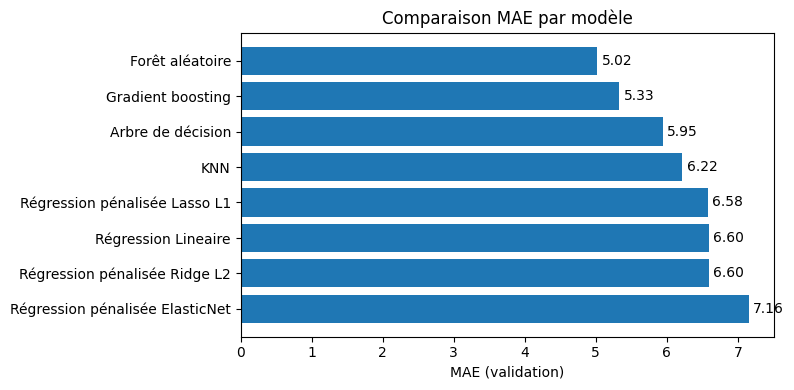

In [59]:
# Comparaison MAE
sorted_df = tracking_df.sort_values('mae_valid', ascending=False)
noms_modeles = sorted_df['model']
mae_values = sorted_df['mae_valid']

plt.figure(figsize=(8, 4))
bars = plt.barh(noms_modeles, mae_values)
plt.bar_label(bars, fmt='%.2f', padding=3)
plt.xlabel('MAE (validation)')
plt.title('Comparaison MAE par modèle')
plt.tight_layout()

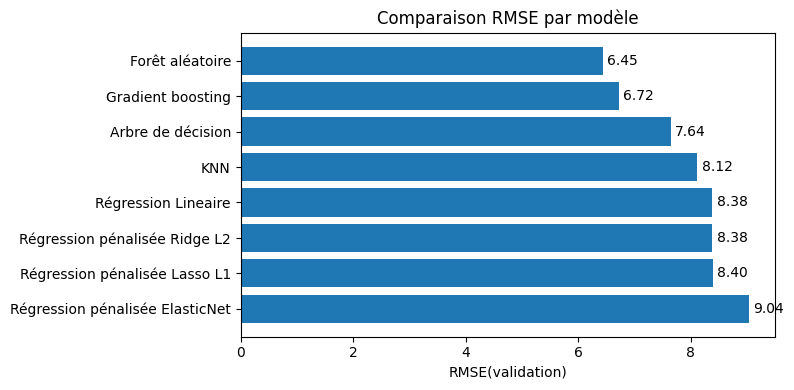

In [60]:
# Comparaison RMSE
sorted_df = tracking_df.sort_values('rmse_valid', ascending=False)
noms_modeles = sorted_df['model']
mae_values = sorted_df['rmse_valid']

plt.figure(figsize=(8, 4))
bars = plt.barh(noms_modeles, mae_values)
plt.bar_label(bars, fmt='%.2f', padding=3)
plt.xlabel('RMSE(validation)')
plt.title('Comparaison RMSE par modèle')
plt.tight_layout()

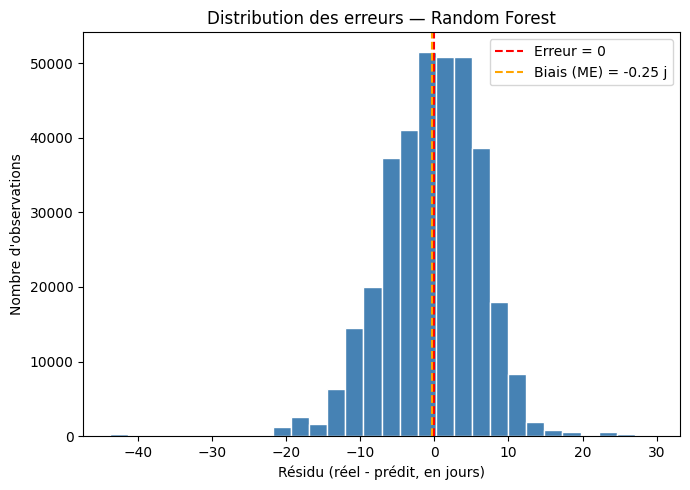

Biais (ME)  : -0.25 j
MAE         : 5.02 j
RMSE        : 6.45 j
% erreur <=3j: 35.5%
% erreur <=7j: 75.4%


In [63]:
# Distribution des erreurs — RandomForest
import pickle

with open('../models/randomforest.pkl', 'rb') as f:
    pipeline_gb = pickle.load(f)

y_pred_gb = pipeline_gb.predict(X_valid)
residus = y_valid - y_pred_gb

fig, ax = plt.subplots(figsize=(7, 5))

# Histogramme des résidus
ax.hist(residus, bins=30, edgecolor='white', color='steelblue')
ax.axvline(0, color='red', linestyle='--', label='Erreur = 0')
ax.axvline(residus.mean(), color='orange', linestyle='--', label=f'Biais (ME) = {residus.mean():.2f} j')
ax.set_xlabel('Résidu (réel - prédit, en jours)')
ax.set_ylabel("Nombre d'observations")
ax.set_title('Distribution des erreurs — Random Forest')
ax.legend()


plt.tight_layout()
plt.show()

print(f"Biais (ME)  : {residus.mean():.2f} j")
print(f"MAE         : {residus.abs().mean():.2f} j")
print(f"RMSE        : {(residus**2).mean()**0.5:.2f} j")
print(f"% erreur <=3j: {(residus.abs() <= 3).mean()*100:.1f}%")
print(f"% erreur <=7j: {(residus.abs() <= 7).mean()*100:.1f}%")


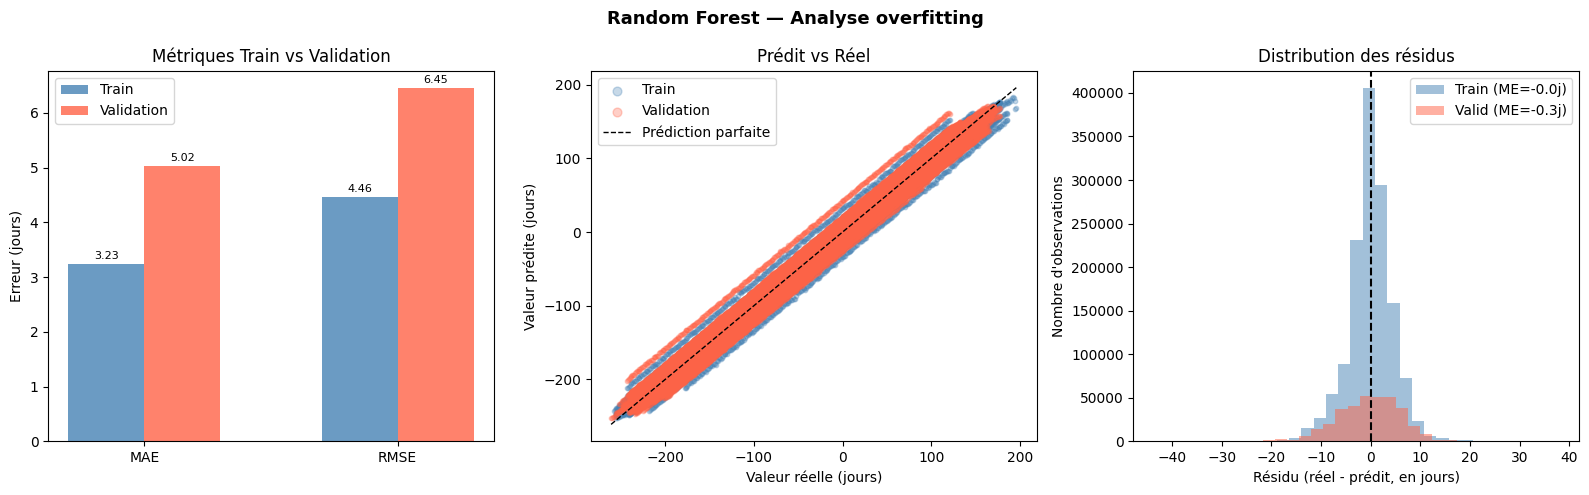

In [65]:
# Overfitting — Random Forest : train vs validation

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred_train_gb = pipeline_gb.predict(X_train)
y_pred_valid_gb = pipeline_gb.predict(X_valid)

mae_train = mean_absolute_error(y_train, y_pred_train_gb)
mae_valid = mean_absolute_error(y_valid, y_pred_valid_gb)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_gb))
rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid_gb))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graphique 1 : Métriques train vs valid
x = [0, 1]
width = 0.3
axes[0].bar([0 - width/2, 1 - width/2], [mae_train, rmse_train], width=width, label="Train", color="steelblue", alpha=0.8)
axes[0].bar([0 + width/2, 1 + width/2], [mae_valid, rmse_valid], width=width, label="Validation", color="tomato", alpha=0.8)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["MAE", "RMSE"])
axes[0].set_title("Métriques Train vs Validation")
axes[0].set_ylabel("Erreur (jours)")
axes[0].legend()
for v, x_pos in zip([mae_train, rmse_train], [0 - width/2, 1 - width/2]):
    axes[0].text(x_pos, v + 0.1, f"{v:.2f}", ha="center", fontsize=8)
for v, x_pos in zip([mae_valid, rmse_valid], [0 + width/2, 1 + width/2]):
    axes[0].text(x_pos, v + 0.1, f"{v:.2f}", ha="center", fontsize=8)

# Graphique 2 : Prédit vs Réel
axes[1].scatter(y_train, y_pred_train_gb, alpha=0.3, s=10, color="steelblue", label="Train")
axes[1].scatter(y_valid, y_pred_valid_gb, alpha=0.3, s=10, color="tomato", label="Validation")
lims = [min(y_train.min(), y_valid.min()), max(y_train.max(), y_valid.max())]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Prédiction parfaite")
axes[1].set_xlabel("Valeur réelle (jours)")
axes[1].set_ylabel("Valeur prédite (jours)")
axes[1].set_title("Prédit vs Réel")
axes[1].legend(markerscale=2)

# Graphique 3 : Distribution des résidus train vs valid 
residus_train = y_train - y_pred_train_gb
residus_valid = y_valid - y_pred_valid_gb
axes[2].hist(residus_train, bins=30, alpha=0.5, color="steelblue", label=f"Train (ME={residus_train.mean():.1f}j)")
axes[2].hist(residus_valid, bins=30, alpha=0.5, color="tomato", label=f"Valid (ME={residus_valid.mean():.1f}j)")
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_xlabel("Résidu (réel - prédit, en jours)")
axes[2].set_ylabel("Nombre d'observations")
axes[2].set_title("Distribution des résidus")
axes[2].legend()

plt.suptitle("Random Forest — Analyse overfitting", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was f

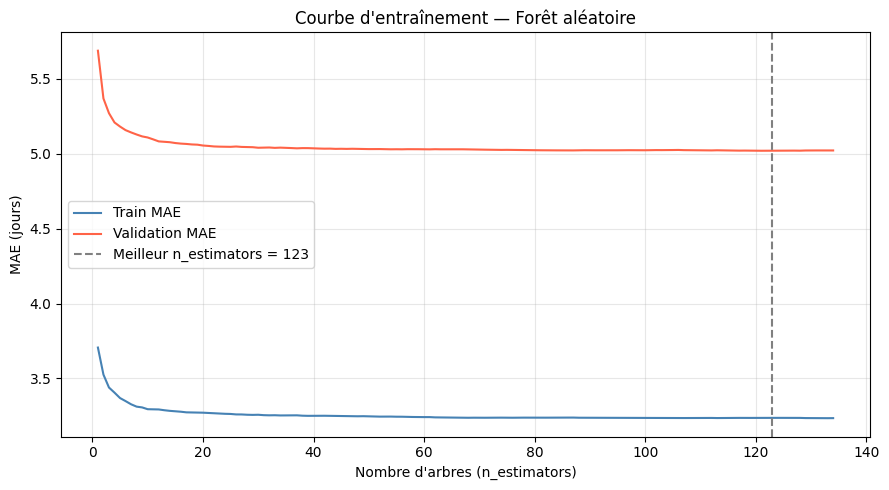

MAE train finale  : 3.235 j
MAE valid finale  : 5.023 j
MAE valid minimale: 5.020 j (à n_estimators=123)


In [66]:
# Courbe d'entraînement — Forêt aléatoire (arbres cumulés)
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

with open('../models/randomforest.pkl', 'rb') as f:
    pipeline_rf = pickle.load(f)

rf_model = pipeline_rf.named_steps['model']
n_estimators = len(rf_model.estimators_)

# Prédictions individuelles par arbre (shape: n_estimators × n_samples)
train_preds = np.array([est.predict(X_train) for est in rf_model.estimators_])
valid_preds = np.array([est.predict(X_valid) for est in rf_model.estimators_])

mae_train_curve = []
mae_valid_curve = []
for k in range(1, n_estimators + 1):
    mae_train_curve.append(mean_absolute_error(y_train, train_preds[:k].mean(axis=0)))
    mae_valid_curve.append(mean_absolute_error(y_valid, valid_preds[:k].mean(axis=0)))

best_n = int(np.argmin(mae_valid_curve)) + 1
n_range = range(1, n_estimators + 1)

plt.figure(figsize=(9, 5))
plt.plot(n_range, mae_train_curve, label='Train MAE', color='steelblue')
plt.plot(n_range, mae_valid_curve, label='Validation MAE', color='tomato')
plt.axvline(best_n, color='gray', linestyle='--', label=f'Meilleur n_estimators = {best_n}')
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel('MAE (jours)')
plt.title("Courbe d'entraînement — Forêt aléatoire")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAE train finale  : {mae_train_curve[-1]:.3f} j")
print(f"MAE valid finale  : {mae_valid_curve[-1]:.3f} j")
print(f"MAE valid minimale: {min(mae_valid_curve):.3f} j (à n_estimators={best_n})")

## Comparaison avec le modèle GDD 

Le seuil est calibré depuis les données d'entraînement (GDD moyen au jour de floraison).  


In [68]:
# ─── Modèle baseline GDD à seuil ────────────────────────────────────────────
#
# Principe : la floraison survient quand le GDD cumulé dépasse un seuil T°.
# Pour estimer "combien de jours restants", on utilise un profil saisonnier
# moyen (GDD cumulé attendu à chaque jour de l'année) construit sur les données
# d'entraînement — et non le taux instantané courant (qui est ≈0 en janvier).
#
# Évaluation restreinte aux lignes pré-floraison (n_avant_floraison >= 0)
# car le modèle GDD est conçu pour prédire un événement futur, pas passé.

#Calcul du seuil moyen
mask_floraison = y_train.abs() <= 2
seuil_gdd = X_train.loc[mask_floraison, 'temps_thermique10'].mean()
print(f"Seuil GDD calibré (moyenne sur {mask_floraison.sum()} obs) : {seuil_gdd:.1f} °C-jours")

# onstruction du profil saisonnier moyen
profil_gdd = X_train.groupby('jour_n')['temps_thermique10'].mean().sort_index()
tous_les_jours = np.arange(1, 366)
profil_gdd_complet = profil_gdd.reindex(tous_les_jours).interpolate(method='linear')
profil_dict = profil_gdd_complet.to_dict()

#Prédiction via le profil saisonnier
def predict_jours_restants(jour_n_vals, gdd_vals, seuil, profil):
    predictions = []
    for jour_n, gdd_actuel in zip(jour_n_vals, gdd_vals):
        jour_n = int(jour_n)
        gdd_actuel = float(gdd_actuel)
        delta = gdd_actuel - profil.get(jour_n, gdd_actuel)
        jour_floraison_pred = None
        for j in range(jour_n, 366):
            if profil.get(j, 0) + delta >= seuil:
                jour_floraison_pred = j
                break
        if jour_floraison_pred is None:
            jour_floraison_pred = 365
        predictions.append(jour_floraison_pred - jour_n)
    return np.array(predictions)

y_pred_gdd = predict_jours_restants(
    X_valid['jour_n'].values,
    X_valid['temps_thermique10'].values,
    seuil_gdd,
    profil_dict
)

#Restriction aux lignes pré-floraison pour l'évaluation globale
mask_pre = y_valid >= 0
print(f"\nLignes pré-floraison dans le valid : {mask_pre.sum():,} / {len(y_valid):,}")

from sklearn.metrics import mean_absolute_error, r2_score

def compute_metrics(y_true, y_pred):
    return {
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'RMSE' : float(np.sqrt(((np.array(y_true) - y_pred) ** 2).mean()))
    }

m_gdd = compute_metrics(y_valid[mask_pre], y_pred_gdd[mask_pre])

print(f"\n{'Métrique':<30} {'Baseline GDD (pré-floraison)':>28}")
print("-" * 60)
for k, v in m_gdd.items():
    print(f"{k:<30} {v:>28.2f}")


print("\n─── Comparaison GDD vs Random Forest (lignes pré-floraison) ──")
if 'tracking_df' in dir():
    import pickle
    meilleur = tracking_df.sort_values('rmse_valid').iloc[0]
    filename = modeles[meilleur['model']]['filename']
    with open(f"{modelsFolder}{filename}", 'rb') as f:
        pipeline_ml = pickle.load(f)

    y_pred_ml = pipeline_ml.predict(X_valid)
    m_ml = compute_metrics(y_valid[mask_pre], y_pred_ml[mask_pre])

    print(f"\n{'Modèle':<35} {'MAE':>8} {'RMSE':>8}")
    print("-" * 71)
    print(f"{'Baseline GDD (seuil thermique)':<35} {m_gdd['MAE']:>8.2f} {m_gdd['RMSE']:>8.2f} ")
    print(f"{meilleur['model']:<35} {m_ml['MAE']:>8.2f} {m_ml['RMSE']:>8.2f}")


Seuil GDD calibré (moyenne sur 19015 obs) : 268.1 °C-jours

Lignes pré-floraison dans le valid : 136,374 / 347,359

Métrique                       Baseline GDD (pré-floraison)
------------------------------------------------------------
MAE                                                    7.06
RMSE                                                   9.17

─── Comparaison GDD vs Random Forest (lignes pré-floraison) ──

Modèle                                   MAE     RMSE
-----------------------------------------------------------------------
Baseline GDD (seuil thermique)          7.06     9.17 
Forêt aléatoire                         4.95     6.35
